# 01 - Audit des données Lmaana

> Notebook 1/3 du rapport final.

Ce notebook décrit les données utilisées par Lmaana 2.1. Il vérifie les volumes, les partitions, la qualité des transcriptions et la différence entre Dataset13, MoulSot original et Lmaana clean. Il ne lance ni préparation ni entraînement.

In [7]:
from pathlib import Path
import json
import sys

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

import pandas as pd
from IPython.display import Image, Markdown, display
from scripts.plot_lmaana_2_1_results import DATASETS

DATA_ROOT = Path.home() / 'badr/badr_data'
REPORTS = PROJECT / 'reports'
FIGURES = PROJECT / 'model_cards/assets/lmaana-2.1'
print('Projet :', PROJECT)
print('Données HPC :', DATA_ROOT)

Projet : /home/skiredj.abderrahman/badr/darija-ctc-lmaana
Données HPC : /home/skiredj.abderrahman/badr/badr_data


## 1. Profil des corpus

Dataset13 apporte la majorité des heures et des segments longs. Lmaana clean contient davantage de segments courts, avec des corrections ciblées des expressions françaises et du code-switching.

In [8]:
dataset_rows = []
for name, values in DATASETS.items():
    dataset_rows.append({
        'corpus': name,
        'train_examples': values['train_examples'],
        'train_hours': values['train_hours'],
        'mean_seconds': values['train_hours'] * 3600 / values['train_examples'],
        'validation_examples': values['validation_examples'],
        'test_examples': values['test_examples'],
    })
profile = pd.DataFrame(dataset_rows)
display(profile.style.format({'train_hours': '{:.2f}', 'mean_seconds': '{:.2f}'}))

hours = profile.set_index('corpus')['train_hours']
natural = hours / hours.sum()
powered = natural.pow(0.5)
effective = powered / powered.sum()
display(pd.DataFrame({'natural_weight': natural, 'effective_beta_0.5': effective}).style.format('{:.2%}'))

,corpus,train_examples,train_hours,mean_seconds,validation_examples,test_examples
0,Dataset13,52892,263.76,17.95,6893,6576
1,Lmaana clean,74243,91.68,4.45,5187,1957


,natural_weight,effective_beta_0.5
corpus,,
Dataset13,74.21%,62.91%
Lmaana clean,25.79%,37.09%


## 2. Rapports d’audit HPC

Les rapports sont chargés lorsqu’ils existent sur le serveur. L’absence locale d’un rapport n’est pas une erreur : les datasets lourds ne sont pas stockés dans Git.

In [9]:
audit_files = {
    'Lmaana clean': DATA_ROOT / 'omniasr_lmaana_clean_v1_reports/lmaana_clean_audit.json',
    'Dataset13 clean': DATA_ROOT / 'omniasr_dataset13_clean_v5_reports/dataset13_omniasr_audit.json',
    'Mélange curriculum': DATA_ROOT / 'omniasr_lmaana_dataset13_clean_mixed_v1_reports/curriculum_mixed_audit.json',
}
audits = {}
for name, path in audit_files.items():
    if path.is_file():
        audits[name] = json.loads(path.read_text(encoding='utf-8'))
    else:
        print(f'Rapport absent ici : {path}')
for name, payload in audits.items():
    display(Markdown(f'### {name}'))
    display(payload)

### Lmaana clean

{'dataset': 'sailu4/lmaanaDataset',
 'source_root': '/home/skiredj.abderrahman/badr/badr_data/lmaanaDataset',
 'labels_csv': '/home/skiredj.abderrahman/badr/badr_data/lmaanaDataset/moulsot_cleaned_for_training.csv',
 'audio_root': '/home/skiredj.abderrahman/badr/badr_data/lmaanaDataset/audio/100-gt-2.5',
 'output': '/home/skiredj.abderrahman/badr/badr_data/omniasr_lmaana_clean_v1',
 'seed': 47,
 'validation_source_fraction': 0.1,
 'min_text_chars': 2,
 'min_audio_seconds': 0.5,
 'labels': {'csv_rows': 81603, 'ready_labels': 81603},
 'validation_sources': ['@AlmofidBdarija',
  '@ElghachiOumm',
  '@Financebdarija',
  '@MrL3ami9',
  '@PILOTA.11',
  '@SANAESLAAAY',
  '@amineaouni',
  '@aymancha7el',
  '@nationalebedarija2',
  '@nouhailalarabi',
  '@salmafadil8854',
  '@youssefzenzouni'],
 'official_test_source_overlap_with_train': [],
 'splits': {'train': {'rows': 74243,
   'sources': 107,
   'hours': 91.67805944444446,
   'parts': 75,
   'rejected': {'audio_too_short': 176,
    'missing_c

### Dataset13 clean

{'dataset': 'pseudolabeling5/Dataset13-batch1_seg_20s_done',
 'source_split': 'train',
 'seed': 47,
 'min_text_chars': 2,
 'min_audio_seconds': 0.5,
 'text_column': 'consensus_transcript',
 'inspected_rows': 66885,
 'usable_rows': 66787,
 'rejected_rows': 98,
 'rejection_reasons': {'quality_reject': 82, 'text_too_short': 16},
 'columns': ['audio',
  'url',
  'segment_order',
  'duration',
  'Source',
  'isma',
  'moulsot_v02',
  'moulsot_v03',
  'arabic_morocco_stt',
  'consensus_transcript'],
 'categories': {'arabic_only': 36971,
  'mixed_arabic_latin': 27384,
  'latin_only': 2411,
  'other': 37},
 'duplicate_normalized_transcriptions': 1359,
 'cross_split_duplicate_texts_removed': 358,
 'cross_split_duplicate_rows_removed': 425,
 'duration_seconds': {'total': 1198804.0644999957,
  'mean': 17.923361957090464,
  'min': 0.9995625,
  'max': 20.0},
 'splits': {'train': {'rows': 52892, 'sources': 341},
  'validation': {'rows': 6894, 'sources': 42},
  'test': {'rows': 6576, 'sources': 42}},

### Mélange curriculum

{'output': '/home/skiredj.abderrahman/badr/badr_data/omniasr_lmaana_dataset13_clean_mixed_v1',
 'link_type': 'hardlink',
 'linked_parquet_files': 142,
 'apparent_bytes': 29609094728,
 'physical_copy_bytes': 0,
 'sources': [{'root': '/home/skiredj.abderrahman/badr/badr_data/omniasr_dataset13_clean_v5',
   'summary': '/home/skiredj.abderrahman/badr/badr_data/omniasr_dataset13_clean_v5_reports/language_distribution.tsv',
   'splits': ['train']},
  {'root': '/home/skiredj.abderrahman/badr/badr_data/omniasr_dataset13_clean_v4',
   'summary': '/home/skiredj.abderrahman/badr/badr_data/omniasr_dataset13_clean_v4_reports/language_distribution.tsv',
   'splits': ['test', 'validation']},
  {'root': '/home/skiredj.abderrahman/badr/badr_data/omniasr_lmaana_clean_v1',
   'summary': '/home/skiredj.abderrahman/badr/badr_data/omniasr_lmaana_clean_v1_reports/language_distribution.tsv',
   'splits': ['train']}],
 'partitions': [{'corpus': 'dataset13',
   'language': 'ary_Arab',
   'split': 'train',
   'n

## 3. Contrôle des partitions

Les partitions Dataset13 ont été séparées par source, puis les doublons textuels entre splits ont été retirés. Lmaana clean utilise aussi des partitions fixes. Aucun exemple de test n’intervient dans la sélection des checkpoints.

In [10]:
expected = pd.DataFrame([
    {'corpus': 'Dataset13', 'split': 'train', 'examples': 52892, 'hours': 263.763336},
    {'corpus': 'Dataset13', 'split': 'validation', 'examples': 6893, 'hours': 33.701771},
    {'corpus': 'Dataset13', 'split': 'test', 'examples': 6576, 'hours': 33.198047},
    {'corpus': 'Lmaana clean', 'split': 'train', 'examples': 74243, 'hours': 91.678059},
    {'corpus': 'Lmaana clean', 'split': 'validation', 'examples': 5187, 'hours': 9.982862},
    {'corpus': 'Lmaana clean', 'split': 'test', 'examples': 1957, 'hours': 3.456848},
])
display(expected.style.format({'hours': '{:.2f}'}))

,corpus,split,examples,hours
0,Dataset13,train,52892,263.76
1,Dataset13,validation,6893,33.70
2,Dataset13,test,6576,33.20
3,Lmaana clean,train,74243,91.68
4,Lmaana clean,validation,5187,9.98
5,Lmaana clean,test,1957,3.46


## 4. Code-switching et corrections

MoulSot original écrivait souvent les mots français phonétiquement en arabe. Lmaana clean corrige une partie de ces labels en alphabet latin. Ce changement améliore la cohérence linguistique mais crée un nouveau protocole : les scores MoulSot historiques ne doivent pas être comparés directement aux scores Lmaana clean.

In [11]:
transcription_report = REPORTS / 'lmaana_2_1_transcription_analysis.json'
if transcription_report.is_file():
    report = json.loads(transcription_report.read_text(encoding='utf-8'))
    display(pd.DataFrame(report['summary']).T)
else:
    print('L’analyse des transcriptions sera produite dans le notebook 03.')

,examples,improved,regressed,unchanged,code_switching,v5_word_errors,lmaana_2_1_word_errors
dataset13,6576,1307,996,4273,2843,114020,113543
lmaana_clean,1957,134,147,1676,230,16323,16334


## 5. Figure de synthèse des datasets

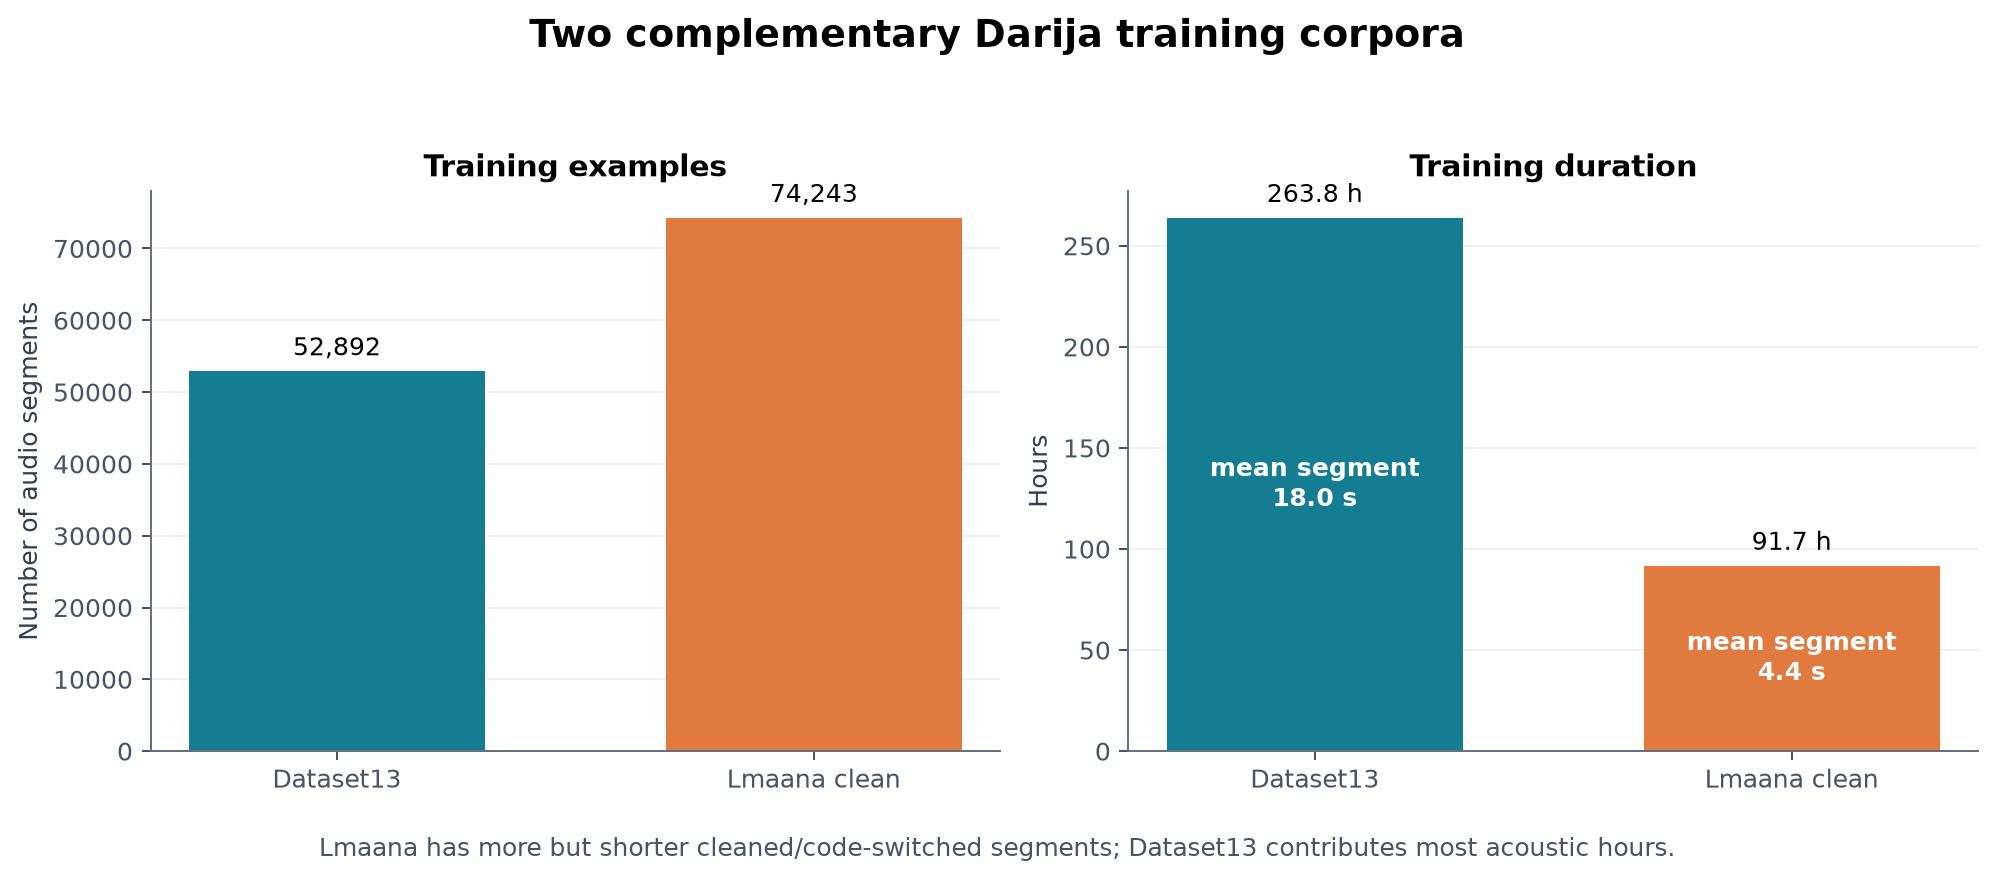

In [12]:
figure = FIGURES / 'dataset_profile.png'
if figure.is_file():
    display(Image(filename=str(figure)))
else:
    print('Figure à générer dans le notebook 03 :', figure)

## Conclusion

Le corpus final combine environ 263,8 h de Dataset13 et 91,7 h de Lmaana clean. Dataset13 couvre la diversité acoustique; Lmaana clean apporte des labels courts et corrigés. La prochaine étape consiste à comparer les stratégies d’adaptation sans mélanger les protocoles d’évaluation.